In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score)


import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/content/loan_approval_dataset.csv")

print(f"dataframe shape : {df.shape}")
print(f"dataframe columns : {df.columns}")
print(f"dataframe info : {df.info()}")
print(f"dataframe describe : {df.describe()}")



dataframe shape : (4269, 13)
dataframe columns : Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64

In [8]:
df = df.copy()

# Clean column names by stripping leading/trailing whitespace
df.columns = df.columns.str.strip()

# Initialize LabelEncoder
le = LabelEncoder()

# First pass: Handle categorical columns (object dtype) with LabelEncoder
for col_name in df.columns:
  if df[col_name].dtype == "object":
    # Convert to string first to handle potential mixed types or NaNs gracefully
    df[col_name] = le.fit_transform(df[col_name].astype(str))

# Second pass: Ensure all columns are numeric and handle remaining NaNs
for col_name in df.columns:
  # Convert to numeric, coercing any non-convertible values to NaN
  df[col_name] = pd.to_numeric(df[col_name], errors="coerce")

  # If there are any NaN values in the column, fill them
  if df[col_name].isnull().any():
    column_mode = df[col_name].mode()
    if not column_mode.empty:
      # Fill NaNs with the most frequent value (mode)
      df[col_name].fillna(column_mode.iloc[0], inplace=True)
    else:
      # If the column became entirely NaN after pd.to_numeric,
      # fill with 0 as a fallback for numerical processing.
      df[col_name].fillna(0, inplace=True)

# Remove df.dropna() as fillna should have handled all NaNs
# df.dropna(inplace = True)

print(f"Null values : {df.isnull().sum()}")

# Separate target variable 'y' and features 'x'
y = df['loan_status']
# Drop 'loan_id' and 'loan_status' from features
x = df.drop(['loan_id', 'loan_status'], axis = 1, inplace = False)

# Ensure no NaNs are left in x or y before scaling/SMOTE
if x.isnull().values.any() or y.isnull().any():
    print("Warning: NaNs detected after preprocessing. Review fillna strategy.")

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_scaled, y)

x_train, x_test, y_train, y_test = train_test_split(
    x_resampled,
    y_resampled,
    stratify = y_resampled,
    test_size = 0.2,
    random_state = 42)


print(f" x_train shape : {x_train.shape}")
print(f" x_test shape : {x_test.shape}")
print(f" y_train shape : {y_train.shape}")
print(f" y_test shape : {y_test.shape}")

Null values : loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
 x_train shape : (4249, 11)
 x_test shape : (1063, 11)
 y_train shape : (4249,)
 y_test shape : (1063,)


In [10]:
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]

pos_weight = neg_count/pos_count

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1,
    scale_pos_weight=pos_weight     # to make sure weight is equal
)

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"""
accuracy : {accuracy}
precision : {precision}
recall : {recall}
f1_score: {f1}
""")


accuracy : 0.9896519285042333
precision : 0.9942965779467681
recall : 0.9849340866290018
f1_score: 0.9895931882686849



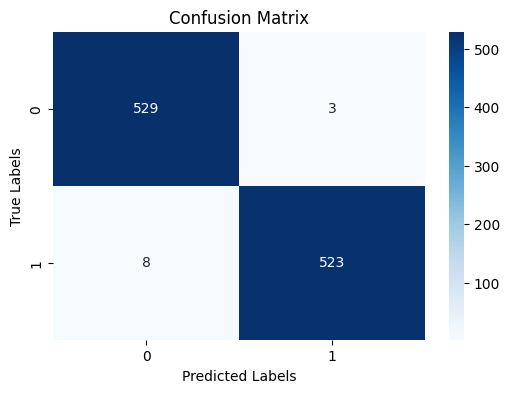

                     feature  importance
6                cibil_score    0.678616
5                  loan_term    0.135247
4                loan_amount    0.031874
3               income_annum    0.028666
0           no_of_dependents    0.021762
9        luxury_assets_value    0.021561
7   residential_assets_value    0.020455
10          bank_asset_value    0.017934
2              self_employed    0.016399
8    commercial_assets_value    0.015517
1                  education    0.011968


['loan_attribution_model.pkl']

In [14]:
plt.figure(figsize = (6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({'feature': x.columns, 'importance': importance})
print(feature_importance.sort_values(by = 'importance', ascending = False))


import joblib

joblib.dump(xgb_model, "loan_attribution_model.pkl")